##Carga de archivo y librerías

In [ ]:
df = pd.read_csv("dataset_horno_fusor2.csv")
df.head(20)

,timestamp,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption
0,2026-02-01 00:00:00,730.005,780.000,92.446,90.584,679.274,19.064,5.023,437.501
1,2026-02-01 00:00:20,733.535,780.001,92.446,90.584,768.807,18.913,5.007,438.777
2,2026-02-01 00:00:40,736.839,780.002,87.769,88.591,675.378,19.801,4.985,412.699
3,2026-02-01 00:01:00,739.829,780.003,86.147,89.818,729.407,18.340,5.018,409.782
4,2026-02-01 00:01:20,742.579,780.005,84.413,90.456,717.542,19.761,4.972,396.238
5,2026-02-01 00:01:40,745.131,780.006,81.889,86.638,730.686,19.558,4.991,386.958
6,2026-02-01 00:02:00,747.441,780.007,81.723,86.424,754.997,19.022,4.980,385.759
7,2026-02-01 00:02:20,749.588,780.008,77.289,85.880,686.521,19.310,4.930,362.759
8,2026-02-01 00:02:40,752.768,780.009,77.328,83.216,718.510,18.742,5.061,372.081
9,2026-02-01 00:03:00,755.631,780.010,77.263,84.662,733.338,18.954,5.070,372.521


In [ ]:
df.tail(10)

,timestamp,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption
21590,2026-02-05 23:56:40,780.885,779.988,57.759,75.372,716.042,18.952,5.002,277.459
21591,2026-02-05 23:57:00,780.912,779.990,57.004,76.160,716.112,19.352,4.984,271.966
21592,2026-02-05 23:57:20,780.905,779.991,58.629,75.359,748.442,18.765,5.055,284.070
21593,2026-02-05 23:57:40,780.953,779.992,58.062,75.863,741.512,19.386,4.949,276.093
21594,2026-02-05 23:58:00,780.945,779.993,59.705,78.557,753.620,19.745,5.090,290.493
21595,2026-02-05 23:58:20,780.953,779.994,57.523,75.653,726.073,19.029,5.007,275.528
21596,2026-02-05 23:58:40,780.975,779.995,59.524,75.987,741.094,19.071,5.028,287.693
21597,2026-02-05 23:59:00,781.031,779.997,59.757,79.481,744.665,19.051,4.979,285.851
21598,2026-02-05 23:59:20,781.064,779.998,57.694,75.527,711.971,19.108,5.018,276.598
21599,2026-02-05 23:59:40,781.100,779.999,56.470,76.517,715.072,19.655,4.954,270.165


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           21600 non-null  object 
 1   sensor_temp         20868 non-null  float64
 2   setpoint            21600 non-null  float64
 3   gas_flow            21600 non-null  float64
 4   air_flow            21600 non-null  float64
 5   furnace_load        21600 non-null  float64
 6   ambient_temp        21600 non-null  float64
 7   gas_pressure        21600 non-null  float64
 8   energy_consumption  21600 non-null  float64
dtypes: float64(8), object(1)
memory usage: 1.5+ MB


## Preprocesamiento de datos

In [ ]:
# Conteo de datos nulos
df.isnull().sum()

,0
timestamp,0
sensor_temp,732
setpoint,0
gas_flow,0
air_flow,0
furnace_load,0
ambient_temp,0
gas_pressure,0
energy_consumption,0


In [ ]:
#Rellenar los datos nulos con la media para no eliminarlos y hacer cálculos con ellos
mean_temp=df.sensor_temp.mean()
print(mean_temp)
df["sensor_temp"]=df["sensor_temp"].fillna(mean_temp)

782.18025551083


In [ ]:
# Convertir timestamp a datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", dayfirst=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           21600 non-null  datetime64[ns]
 1   sensor_temp         21600 non-null  float64       
 2   setpoint            21600 non-null  float64       
 3   gas_flow            21600 non-null  float64       
 4   air_flow            21600 non-null  float64       
 5   furnace_load        21600 non-null  float64       
 6   ambient_temp        21600 non-null  float64       
 7   gas_pressure        21600 non-null  float64       
 8   energy_consumption  21600 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 1.5 MB


In [ ]:
# Rango de fechas
min_date = df["timestamp"].min()
max_date = df["timestamp"].max()
print(min_date)
print(max_date)

2026-01-02 00:00:00
2026-05-02 23:59:40


In [ ]:
# Revisar duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Ordenar just in case
df = df.sort_values("timestamp").reset_index(drop=True)

In [ ]:
#Preparación de columnas para el modelo
df = df.rename(columns={"sensor_temp": "y", "timestamp": "ds"})

In [ ]:
df = df.sort_values("ds").reset_index(drop=True)
n = len(df)

train_size = int(0.70 * n)
val_size   = int(0.15 * n)

train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size + val_size].copy()
test_df  = df.iloc[train_size + val_size:].copy()

print(f"Train: {len(train_df)} muestras ({train_df['ds'].min()} a {train_df['ds'].max()})")
print(f"Val:   {len(val_df)} muestras ({val_df['ds'].min()} a {val_df['ds'].max()})")
print(f"Test:  {len(test_df)} muestras ({test_df['ds'].min()} a {test_df['ds'].max()})")

Train: 15119 muestras (2026-01-02 00:00:00 a 2026-04-02 11:59:20)
Val:   3240 muestras (2026-04-02 11:59:40 a 2026-05-02 05:59:20)
Test:  3241 muestras (2026-05-02 05:59:40 a 2026-05-02 23:59:40)


## Análisis exploratorio de datos (básico)

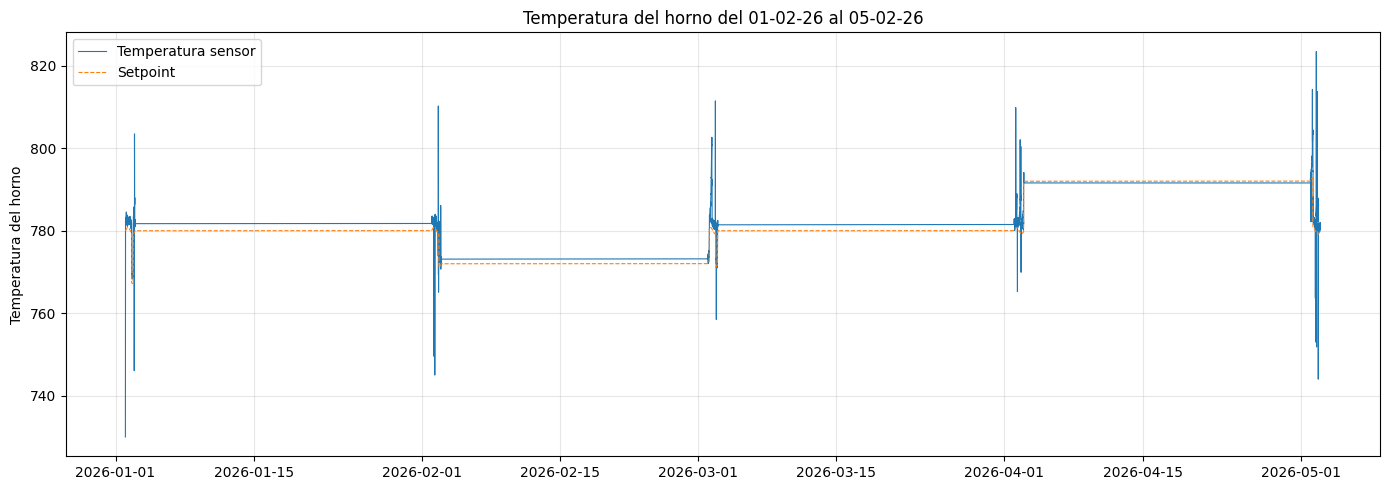

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["ds"], df["y"], linewidth=0.8, label="Temperatura sensor")
plt.plot(df["ds"], df["setpoint"], linewidth=0.8, label="Setpoint", linestyle="--")
plt.title("Temperatura del horno del 01-02-26 al 05-02-26")
plt.ylabel("Temperatura del horno")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

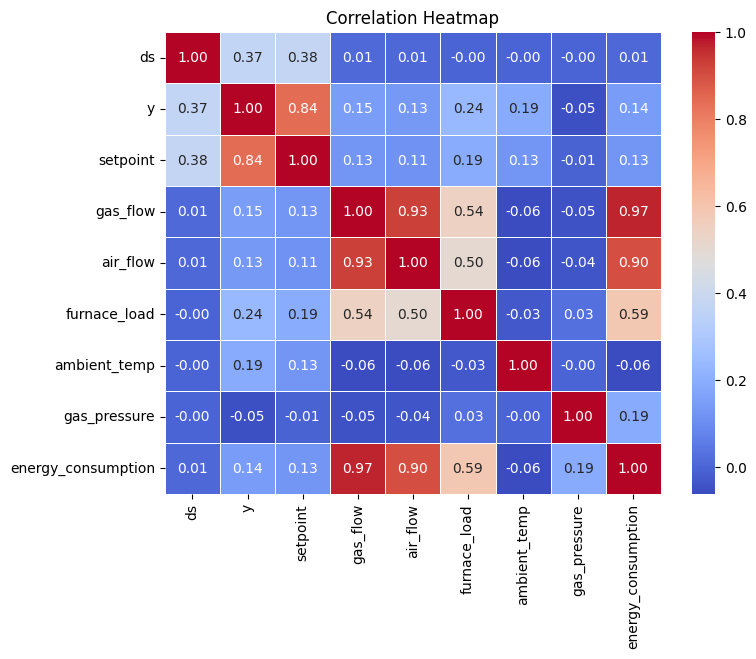

In [ ]:
#Matriz de correlación
matrix = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modelo baseline sin perturbaciones

In [ ]:
#Df con timestamp y sensor_temp
df_m1 = df[["ds", "y"]].copy()

In [ ]:
m1 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=True,
    interval_width=0.95
)

In [ ]:
m1.fit(df_m1)

In [ ]:
forecast_m1 = m1.predict(df_m1)

## Modelo baseline con perturbaciones

In [ ]:
regressor_cols = ["gas_flow", "air_flow", "furnace_load",
                  "ambient_temp", "gas_pressure", "energy_consumption"]

scaler = MinMaxScaler()
df_regressors_scaled = pd.DataFrame(
    scaler.fit_transform(df[regressor_cols]),
    columns=[f"{col}_scaled" for col in regressor_cols]
)

In [ ]:
df_m2 = pd.concat([df[["ds", "y"]], df_regressors_scaled], axis=1)

In [ ]:
m2 = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=True,
    interval_width=0.95
)

In [ ]:
for col in df_regressors_scaled.columns:
    m2.add_regressor(col, standardize=False)

In [ ]:
m2.fit(df_m2)

In [ ]:
forecast_m2 = m2.predict(df_m2)

## Evaluación de precisión de los modelos base

In [ ]:
#Métricas de error del modelo
mae_m1  = mean_absolute_error(df_m1["y"], forecast_m1["yhat"])
rmse_m1 = np.sqrt(mean_squared_error(df_m1["y"], forecast_m1["yhat"]))
mape_m1 = np.mean(np.abs((df_m1["y"].values - forecast_m1["yhat"].values) / df_m1["y"].values)) * 100

print("Modelo 1 sin perturbaciones")
print(f"  MAE  : {mae_m1:.4f} °C")
print(f"  RMSE : {rmse_m1:.4f} °C")
print(f"  MAPE : {mape_m1:.4f} %")

Modelo 1 sin perturbaciones
  MAE  : 2.9310 °C
  RMSE : 3.9700 °C
  MAPE : 0.3744 %


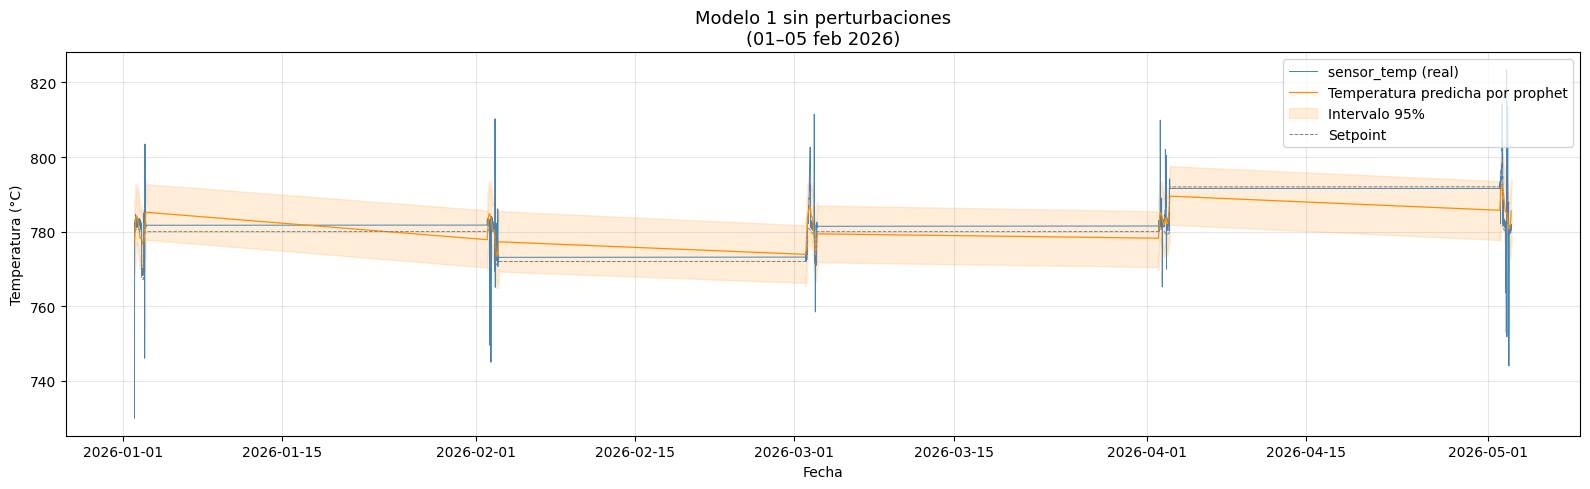

In [ ]:
#Gráfica comparativa
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_m1["ds"], df_m1["y"],
        color="steelblue", linewidth=0.7, label="sensor_temp (real)")

ax.plot(forecast_m1["ds"], forecast_m1["yhat"],
        color="darkorange", linewidth=0.9, label="Temperatura predicha por prophet")

ax.fill_between(forecast_m1["ds"],
                forecast_m1["yhat_lower"],
                forecast_m1["yhat_upper"],
                color="darkorange", alpha=0.15, label="Intervalo 95%")
ax.plot(df["ds"], df["setpoint"],
        color="gray", linewidth=0.7, linestyle="--", label="Setpoint")

ax.set_title("Modelo 1 sin perturbaciones\n(01–05 feb 2026)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ── 1. Extraer pesos de los regresores ──────────────────────────────────────
# Prophet guarda los parámetros en m2.params (dict de arrays stan)

def extraer_formula_prophet(modelo, regressor_cols):
    """
    Devuelve los coeficientes beta de cada regresor y
    construye la 'ecuación' del modelo.
    """
    params = modelo.params  # dict con arrays de la cadena MCMC/MAP

    # beta: shape (n_samples, n_regressors) — tomamos la media
    betas = params['beta'].mean(axis=0)  # un valor por regresor

    # k = tasa de crecimiento, m = offset, delta = changepoints
    k = float(params['k'].mean())
    m = float(params['m'].mean())

    print("=" * 55)
    print("COMPONENTE TENDENCIA (lineal):")
    print(f"  y_trend(t) = {k:.6f} * t + {m:.6f}")
    print()
    print("COMPONENTE REGRESORES (escalados con MinMaxScaler):")
    coef_dict = {}
    for i, col in enumerate(regressor_cols):
        col_scaled = f"{col}_scaled"
        beta = betas[i]
        coef_dict[col_scaled] = beta
        print(f"  β_{col:25s} = {beta:+.6f}")
    print()
    print("FÓRMULA COMPLETA (aprox):")
    terms = " + ".join([f"({v:.4f})*{k}" for k, v in coef_dict.items()])
    print(f"  ŷ(t) = trend(t) + seasonality(t) + {terms}")
    print("=" * 55)
    return coef_dict

# ── 2. También extraer la estacionalidad diaria ─────────────────────────────
def extraer_estacionalidad(modelo, nombre='daily', n_puntos=24):
    """Evalúa la componente de estacionalidad en 24h."""
    from prophet.utilities import regressor_coefficients
    future = modelo.make_future_dataframe(periods=0, freq='min')
    components = modelo.predict_seasonal_components(
        modelo.predict(future.iloc[:n_puntos*60])
    ) if hasattr(modelo, 'predict_seasonal_components') else None
    return components

# ── 3. Uso ───────────────────────────────────────────────────────────────────
regressor_cols = ["gas_flow", "air_flow", "furnace_load",
                  "ambient_temp", "gas_pressure", "energy_consumption"]

coefs = extraer_formula_prophet(m2, regressor_cols)

# Tabla limpia para el reporte
df_coefs = pd.DataFrame({
    'Regresor': regressor_cols,
    'Beta (peso)': [coefs[f"{c}_scaled"] for c in regressor_cols]
})
print(df_coefs.to_string(index=False))

COMPONENTE TENDENCIA (lineal):
  y_trend(t) = 0.896949 * t + 0.942300

COMPONENTE REGRESORES (escalados con MinMaxScaler):
  β_gas_flow                  = +0.006913
  β_air_flow                  = -0.000225
  β_furnace_load              = +0.001975
  β_ambient_temp              = -0.000409
  β_gas_pressure              = +0.000018
  β_energy_consumption        = +0.000187

FÓRMULA COMPLETA (aprox):
  ŷ(t) = trend(t) + seasonality(t) + (0.0069)*gas_flow_scaled + (-0.0002)*air_flow_scaled + (0.0020)*furnace_load_scaled + (-0.0004)*ambient_temp_scaled + (0.0000)*gas_pressure_scaled + (0.0002)*energy_consumption_scaled
          Regresor  Beta (peso)
          gas_flow     0.006913
          air_flow    -0.000225
      furnace_load     0.001975
      ambient_temp    -0.000409
      gas_pressure     0.000018
energy_consumption     0.000187


In [ ]:
#Métricas de error del modelo 2
mae_m2  = mean_absolute_error(df_m2["y"], forecast_m2["yhat"])
rmse_m2 = np.sqrt(mean_squared_error(df_m2["y"], forecast_m2["yhat"]))
mape_m2 = np.mean(np.abs((df_m2["y"].values - forecast_m2["yhat"].values) / df_m2["y"].values)) * 100

print("Modelo 2 con perturbaciones")
print(f"  MAE  : {mae_m2:.4f} °C")
print(f"  RMSE : {rmse_m2:.4f} °C")
print(f"  MAPE : {mape_m2:.4f} %")

Modelo 2 con perturbaciones
  MAE  : 2.8098 °C
  RMSE : 3.7891 °C
  MAPE : 0.3589 %


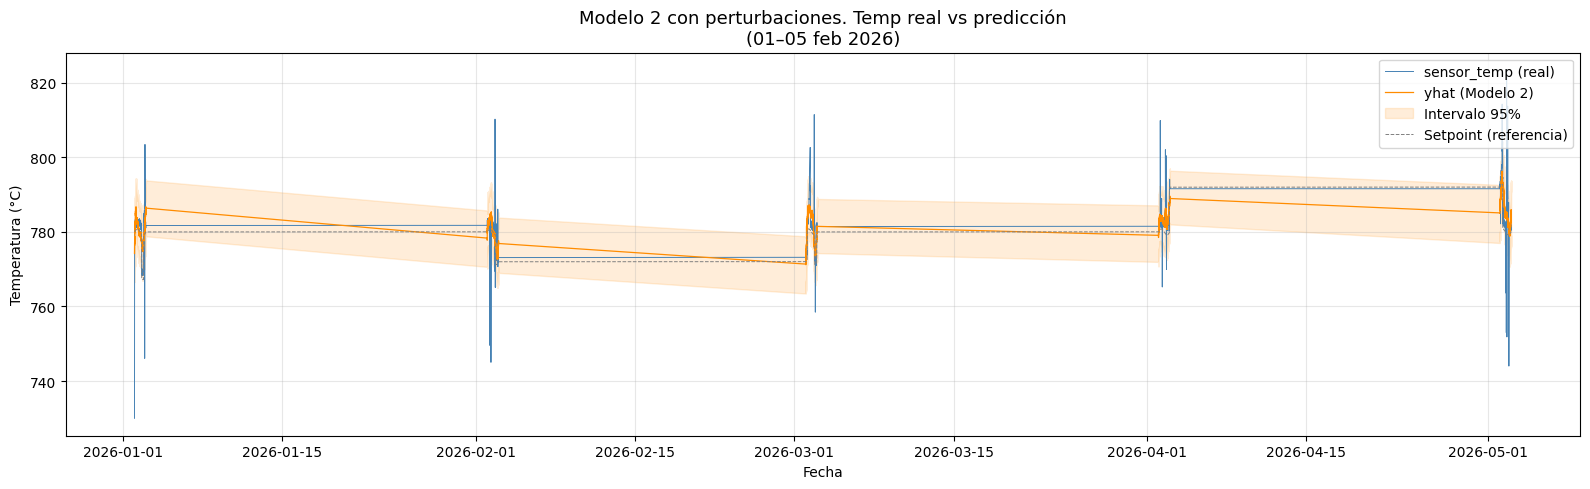

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_m2["ds"], df_m2["y"],
        color="steelblue", linewidth=0.7, label="sensor_temp (real)")

ax.plot(forecast_m2["ds"], forecast_m2["yhat"],
        color="darkorange", linewidth=0.9, label="yhat (Modelo 2)")

ax.fill_between(forecast_m2["ds"],
                forecast_m2["yhat_lower"],
                forecast_m2["yhat_upper"],
                color="darkorange", alpha=0.15, label="Intervalo 95%")

ax.plot(df["ds"], df["setpoint"],
        color="gray", linewidth=0.7, linestyle="--", label="Setpoint (referencia)")

ax.set_title("Modelo 2 con perturbaciones. Temp real vs predicción\n(01–05 feb 2026)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Temperatura (°C)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()